In [3]:
# https://raw.githubusercontent.com/Pankaj-Str/Complete-Python-Mastery/refs/heads/main/53%20DataSet/Mall_Customers.csv

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
df = pd.read_csv("https://raw.githubusercontent.com/Pankaj-Str/Complete-Python-Mastery/refs/heads/main/53%20DataSet/Mall_Customers.csv")

print(df.head())

X = df[['Annual Income (k$)','Spending Score (1-100)']].values
scaler = StandardScaler()
X_scaler = scaler.fit_transform(X)

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [32]:
# apply DBscan

dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
).fit(X)

labels = dbscan.fit_predict(X_scaler)

labels = dbscan.labels_

df['Cluster'] = labels

uniquelabels = set(labels)
print(uniquelabels)


{np.int64(0), np.int64(1), np.int64(-1)}


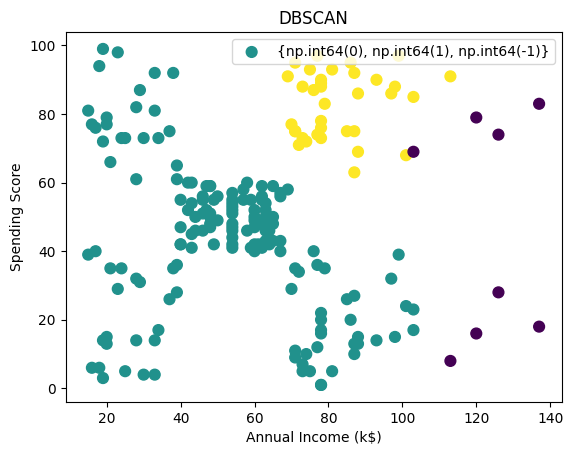

Cluster
 0    157
 1     35
-1      8
Name: count, dtype: int64


In [34]:
plt.scatter(df['Annual Income (k$)'],df['Spending Score (1-100)'],c=df['Cluster'],cmap='viridis',s=60,
            label=uniquelabels)
plt.title('DBSCAN')
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.legend()
plt.show()

print(df['Cluster'].value_counts())